# Machine Learning Powered Cardiovascular Disease Detection Tool
---

### Introduction:

Cardiac disease is the leading cause of death worldwide. Distinguishing between different cardiac conditions especially in patients with overlapping symptoms  is one of the most challenging tasks in clinical medicine.

This project builds a machine learning classifier that can distinguish between four patient classes(four cardio dizeaze typez) based on 16 clinical features (9 continuous measurements and 7 categorical symptoms). The dataset is synthetic but generated from peer-reviewed clinical statistics, ensuring the distributions are medically realistic.

The Project is divided into four parts. They are :


| Phase | Topic |
|----------|-------|
| 1 | Synthetic Dataset Generator |
| 2 | EDA, Modelling and Evaluation |
| 3 | GUI using Gradio |
| 4 | Report |

---

### Phase- 1: Synthetic Dataset Generation

#### Why Synthetic Data?

Real cardiac datasets are either proprietary, small, or heavily de-identified.  
Synthetic data lets us:
- Control the degree of **class overlap** (making the classification realistically hard)
- Guarantee **balanced classes** (equal patients per condition)
- Share data **freely** without privacy concerns

The four classes which will be used in the model along with the 16 common features are listed below:

### 4 Classes

| Label | Class | Description |
|-------|-------|-------------|
| 0 | Healthy | No diagnosed cardiac condition.|
| 1 | CAD | Coronary Artery Disease. Atherosclerotic plaque in coronary arteries reduces blood flow to the heart muscle. |
| 2 | Arrhythmia | Abnormal electrical rhythm including Atrial Fibrillation, Ventricular Tachycardia, and Tachy/Brady patterns. |
| 3 | Heart Failure | Structural or functional impairment of ventricular filling or ejection. |

###  16 Features

#### Continuous Features

| Feature | Full Name | Unit | Clinical Meaning |
|---------|-----------|------|-----------------|
| **Age** | Patient age | years | Older age increases all cardiac disease risk |
| **BMI** | Body Mass Index | kg/m² | Weight relative to height; ≥30 = obese |
| **Systolic BP** | Systolic Blood Pressure | mmHg | Peak arterial pressure |
| **LDL** | Low Density Lipoprotein cholesterol | mg/dL | Bad cholesterol; drives arterial plaque in CAD |
| **Fasting Glucose** | Blood sugar after ≥8 hr fast | mg/dL | Blood glucose measured after at least 8 hours of fasting. |
| **Heart Rate** | Resting pulse | bpm | Resting heart rate in beats per minute.  |
| **SpO₂** | Peripheral oxygen saturation | % | The percentage of haemoglobin carrying oxygen, measured by pulse oximetry |
| **EF** | Ejection Fraction | % | The percentage of blood pumped out of the left ventricle with each heartbeat. |
| **BNP** | B-type Natriuretic Peptide | pg/mL | A hormone released by heart muscle cells under pressure or stretch. |

#### Categorical Features

| Feature | Scale | Clinical Meaning |
|---------|-------|-----------------|
| **SOB** | 0=None, 1=Mild, 2=Moderate, 3=Severe | Shortness of Breath at rest or on exertion |
| **Chest Tightness** | 0=None, 1=Non-anginal, 2=Typical angina | Quality of chest discomfort |
| **Smoking** | 0=Never, 1=Light, 2=Moderate, 3=Heavy | Cumulative tobacco exposure |
| **Diabetes** | 0=Normal, 1=Pre-diabetes, 2=Type 2, 3=Type 1 | Glycaemic status; diabetes doubles cardiac risk |
| **Edema** | 0=None, 1=Mild, 2=Severe | Peripheral fluid retention |
| **Palpitations** | 0=None, 1=Occasional, 2=Frequent | Sensation of abnormal heartbeat |
| **ECG** | 0=Normal, 1=Tachy/Brady, 2=AF, 3=VT | Electrocardiogram finding|


In [16]:
import numpy as np
import pandas as pd
import pickle
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import truncnorm


warnings.filterwarnings('ignore')
np.random.seed(32)

CLASS_NAMES  = ['Healthy', 'CAD', 'Arrhythmia', 'Heart Failure']
CLASS_COLORS = ['#27ae60', '#e74c3c', '#f39c12', '#8e44ad']

CONT_COLS = ['age', 'bmi', 'systolic_bp', 'ldl', 'fasting_glucose',
             'heart_rate', 'spo2', 'ejection_fraction', 'bnp']

CAT_COLS  = ['sob', 'chest_tightness', 'smoking', 'diabetes',
             'edema', 'palpitations', 'ecg']

N = 1500   # patients per class

## Understanding Range, Mean, and Standard Deviation

This is the most important concept in this notebook. Every continuous feature is generated using a **normal (bell-curve) distribution** defined by three numbers.

**What is the Mean?**
The most typical (centre) value in the distribution. We calculate it as the midpoint of the range:
> **Mean = (Low + High) ÷ 2**

For Healthy age: Mean = (20 + 75) ÷ 2 = 47.5 ≈ **48**

**What is the Standard Deviation (SD)?**
SD measures how spread out the values are around the mean. A larger SD means more patients have values far from the mean; a smaller SD means most patients cluster near the mean. We calculate it so that **95% of all generated patients fall within the source range**:
> **SD = (High − Low) ÷ 4**

For Healthy age: SD = (75-20) ÷ 4 = 13.75 ≈ **14**

**Why does SD = (High - Low) ÷ 4 give us 95% coverage?**
In any normal distribution, exactly 95% of all values fall between Mean − 2×SD and Mean + 2×SD. So:
- Lower limit = Mean − 2×SD = 48 − 2×14 = **20**  matches the range
- Upper limit = Mean + 2×SD = 48 + 2×14 = **76**  matches the range

The remaining 5% of generated patients fall slightly outside the range — these are the atypical cases that exist in every real population.

**Worked Example: Healthy BMI (source range 18.5–40):**
- Mean = (18.5 + 40) ÷ 2 = 29.25 ≈ **29** ← matches NHANES US adult mean of 29.23
- SD = (40 − 18.5) ÷ 4 = 5.375 ≈ **5**
- Check: 29 − 2×5 = 19  | 29 + 2×5 = 39

**Why BNP uses a different distribution (Log-Normal)?**
BNP cannot be modelled with a bell curve because it is always positive and most people have low values while a small number have extremely high values (right-skewed). A log-normal distribution fits this shape. For log-normal, we set parameters in log-space:
> **mu_log = (log(Low) + log(High)) ÷ 2**
> **sd_log = (log(High) − log(Low)) ÷ 4**

**Worked Example: Healthy BNP (source range 5–200):**
- log(5) = 1.61, log(200) = 5.30
- mu_log = (1.61 + 5.30) ÷ 2 = **3.45** → exp(3.45) ≈ 32 pg/mL (median)
- sd_log = (5.30 − 1.61) ÷ 4 = **0.92**
- Check: 95% of values between exp(3.45 − 2×0.92) ≈ 5 and exp(3.45 + 2×0.92) ≈ 200 

## Defining the Functions that help to genertate the data.

- **`tnorm`** - truncated normal distribution (no edge spikes)
- **`lognorm_trunc`** - truncated log-normal for BNP (right-skewed biomarker)
- **`cat`** - categorical sampling
- **`N=4000`** - No of zamplez for each clazz

In [17]:
SEED = 42

def tnorm(mean, sd, lo, hi, n=N):
    a = (lo - mean) / sd
    b = (hi - mean) / sd
    return truncnorm.rvs(a, b, loc=mean, scale=sd, size=n)

def lognorm_trunc(mu_log, sd_log, lo, hi, n=N):
    a = (np.log(lo) - mu_log) / sd_log
    b = (np.log(hi) - mu_log) / sd_log
    lv = truncnorm.rvs(a, b, loc=mu_log, scale=sd_log, size=n)
    return np.exp(lv)

def cat(vals, probs, n=N):
    return np.random.choice(vals, n, p=probs)


In [18]:
# Healthy
age_H0  = tnorm(48, 14, 20,   75)   # range 20-75
bmi_H0  = tnorm(29,  5, 18.5, 40)   # NHANES mean 29.23
sbp_H0  = tnorm(124, 12, 100, 148)
ldl_H0  = tnorm(128, 34, 60,  195)
glc_H0  = tnorm(98,  14, 70,  125)
hr_H0   = tnorm(78,  11, 55,  100)
spo2_H0 = tnorm(97,  1.5, 94, 100)
ef_H0   = tnorm(62,  7,  48,  76)
bnp_H0  = lognorm_trunc(3.45, 0.92, 5, 200)  # log-normal

sob_H0  = cat([0,1,2,3], [0.80,0.20,0.00,0.00])
ct_H0   = cat([0,1,2],   [0.87,0.11,0.02])
sm_H0   = cat([0,1,2,3], [0.65,0.20,0.12,0.03])
dm_H0   = cat([0,1,2,3], [0.66,0.26,0.07,0.01])
ed_H0   = cat([0,1,2],   [0.93,0.06,0.01])
pal_H0  = cat([0,1,2],   [0.38,0.55,0.07])
ecg_H0  = cat([0,1,2,3], [0.80,0.18,0.02,0.00])

print('Healthy generated.')


Healthy generated.


In [19]:
#CAD
age_H1  = tnorm(61, 11, 40,  82)
bmi_H1  = tnorm(33,  6, 22,  44)
sbp_H1  = tnorm(153, 18, 118, 188)
ldl_H1  = tnorm(175, 45, 85,  265)
glc_H1  = tnorm(145, 33, 80,  210)
hr_H1   = tnorm(80,  16, 48,  112)
spo2_H1 = tnorm(94,   3, 88,  99)
ef_H1   = tnorm(51,  10, 32,  70)
bnp_H1  = lognorm_trunc(5.23, 0.57, 60, 580)

sob_H1  = cat([0,1,2,3], [0.28,0.38,0.24,0.10])
ct_H1   = cat([0,1,2],   [0.20,0.38,0.42])
sm_H1   = cat([0,1,2,3], [0.44,0.22,0.22,0.12])
dm_H1   = cat([0,1,2,3], [0.42,0.18,0.30,0.10])
ed_H1   = cat([0,1,2],   [0.64,0.28,0.08])
pal_H1  = cat([0,1,2],   [0.30,0.50,0.20])
ecg_H1  = cat([0,1,2,3], [0.22,0.42,0.28,0.08])

print('CAD generated.')


CAD generated.


In [20]:
# Arrhythmia 
age_H2  = tnorm(58, 15, 28,  88)
bmi_H2  = tnorm(31,  6, 20,  42)
sbp_H2  = tnorm(145, 19, 108, 182)
ldl_H2  = tnorm(147, 39, 68,  225)
glc_H2  = tnorm(127, 26, 75,  178)
hr_H2   = tnorm(102, 32, 38,  165)   # SD=32 widest — AF causes irregular HR
spo2_H2 = tnorm(93,   3, 86,  99)
ef_H2   = tnorm(54,   9, 35,  72)
bnp_H2  = lognorm_trunc(4.70, 0.85, 20, 600)

sob_H2  = cat([0,1,2,3], [0.30,0.38,0.24,0.08])
ct_H2   = cat([0,1,2],   [0.62,0.28,0.10])
sm_H2   = cat([0,1,2,3], [0.54,0.22,0.18,0.06])
dm_H2   = cat([0,1,2,3], [0.58,0.20,0.18,0.04])
ed_H2   = cat([0,1,2],   [0.74,0.22,0.04])
pal_H2  = cat([0,1,2],   [0.22,0.40,0.38])
ecg_H2  = cat([0,1,2,3], [0.14,0.38,0.28,0.20])

print('Arrhythmia generated.')
print(f'  HR {hr_H2.min():.0f}-{hr_H2.max():.0f}  mean {hr_H2.mean():.0f}  sd {hr_H2.std():.0f}')


Arrhythmia generated.
  HR 38-165  mean 102  sd 28


In [21]:
# Heart Failure
age_H3  = tnorm(65, 13, 40,  90)
bmi_H3  = tnorm(31,  7, 17,  44)
sbp_H3  = tnorm(146, 23, 100, 192)
ldl_H3  = tnorm(134, 43, 48,  220)
glc_H3  = tnorm(193, 59, 76,  310)
hr_H3   = tnorm(89,  22, 46,  132)
spo2_H3 = tnorm(91,   4, 82,  99)
ef_H3   = tnorm(58,   9, 40,  75)
bnp_H3  = lognorm_trunc(5.79, 1.11, 35, 3000)

sob_H3  = cat([0,1,2,3], [0.20,0.30,0.32,0.18])
ct_H3   = cat([0,1,2],   [0.40,0.42,0.18])
sm_H3   = cat([0,1,2,3], [0.52,0.22,0.18,0.08])
dm_H3   = cat([0,1,2,3], [0.30,0.14,0.42,0.14])
ed_H3   = cat([0,1,2],   [0.28,0.38,0.34])   # 28% no edema: COACH study
pal_H3  = cat([0,1,2],   [0.32,0.36,0.32])
ecg_H3  = cat([0,1,2,3], [0.10,0.28,0.32,0.30])

print('Heart Failure generated.')


Heart Failure generated.


## Assembling the Base Dataset

As we defined the 4 class functions, we now combine all four class arrays into one table. Next we build a function that combines all the classes.

- **build_class()** — a simple function that packages one class's arrays into a pandas DataFrame (table). We call it four times, once per class.
- **pd.concat([t0, t1, t2, t3])** — stacks the four tables vertically into one 2400-row table.
- **.sample(frac=1, random_state=42)** — shuffles all rows randomly so the classes are mixed together instead of appearing in blocks.
- **.reset_index(drop=True)** — after shuffling the row numbers become scrambled. This resets them to 0, 1, 2, ..., 9999.
- The final `.clip()` calls enforce physiological limits on each column. For example SpO₂ cannot exceed 100%, heart rate cannot be below 20 bpm.

In [22]:
def build_table(label_str, cont_arrays, cat_arrays):
    d = {}
    for col, arr in zip(CONT_COLS, cont_arrays):
        d[col] = arr
    for col, arr in zip(CAT_COLS, cat_arrays):
        d[col] = arr
    t = pd.DataFrame(d)
    t['target'] = label_str
    return t

t0 = build_table('Healthy',
    [age_H0,bmi_H0,sbp_H0,ldl_H0,glc_H0,hr_H0,spo2_H0,ef_H0,bnp_H0],
    [sob_H0,ct_H0,sm_H0,dm_H0,ed_H0,pal_H0,ecg_H0])

t1 = build_table('CAD',
    [age_H1,bmi_H1,sbp_H1,ldl_H1,glc_H1,hr_H1,spo2_H1,ef_H1,bnp_H1],
    [sob_H1,ct_H1,sm_H1,dm_H1,ed_H1,pal_H1,ecg_H1])

t2 = build_table('Arrhythmia',
    [age_H2,bmi_H2,sbp_H2,ldl_H2,glc_H2,hr_H2,spo2_H2,ef_H2,bnp_H2],
    [sob_H2,ct_H2,sm_H2,dm_H2,ed_H2,pal_H2,ecg_H2])

t3 = build_table('Heart Failure',
    [age_H3,bmi_H3,sbp_H3,ldl_H3,glc_H3,hr_H3,spo2_H3,ef_H3,bnp_H3],
    [sob_H3,ct_H3,sm_H3,dm_H3,ed_H3,pal_H3,ecg_H3])

df_base = pd.concat([t0,t1,t2,t3], ignore_index=True)
df_base = df_base.sample(frac=1, random_state=42).reset_index(drop=True)
print('Base dataset haz been generated.')


Base dataset haz been generated.


In [23]:
print(f'Shape   : {df_base.shape}')
print(f'Columns : {list(df_base.columns)}')
print(f'Classes : {df_base.target.value_counts().to_dict()}')
print()

Shape   : (6000, 17)
Columns : ['age', 'bmi', 'systolic_bp', 'ldl', 'fasting_glucose', 'heart_rate', 'spo2', 'ejection_fraction', 'bnp', 'sob', 'chest_tightness', 'smoking', 'diabetes', 'edema', 'palpitations', 'ecg', 'target']
Classes : {'CAD': 1500, 'Arrhythmia': 1500, 'Healthy': 1500, 'Heart Failure': 1500}



## Add Medical Relationships (Enriched Dataset)

The base dataset treats each feature as independently generated. But in real patients, features are clinically connected. 

In [24]:
df_enriched = df_base.copy()

# R1: SBP rises with BMI above 25 
# 0.5 mmHg per BMI unit above 25  (sympathetic activation, cardiac output)
bmi_above_25 = (df_enriched['bmi'] - 25).clip(lower=0)
df_enriched['systolic_bp'] = df_enriched['systolic_bp'] + 0.5 * bmi_above_25

# R2: SBP rises with age above 40 
# 0.4 mmHg per year above 40  (arterial stiffening)
age_above_40 = (df_enriched['age'] - 40).clip(lower=0)
df_enriched['systolic_bp'] = df_enriched['systolic_bp'] + 0.4 * age_above_40

# R3: Fasting glucose rises with diabetes severity
# Each diabetes level adds 15 mg/dL  (pre-DM +15, T2 +30, T1 +45)
df_enriched['fasting_glucose'] = (df_enriched['fasting_glucose']
                                   + 15 * df_enriched['diabetes'])

#R4: LDL rises with smoking level
# Each smoking level adds 12 mg/dL  (nicotine oxidises LDL, lowers HDL)
df_enriched['ldl'] = df_enriched['ldl'] + 12 * df_enriched['smoking']

# R5: BNP rises as EF falls below 50 
# 10 pg/mL per unit EF below 50  (ventricular wall stretch releases BNP)
ef_deficit = (50 - df_enriched['ejection_fraction']).clip(lower=0)
df_enriched['bnp'] = df_enriched['bnp'] + 10 * ef_deficit

# R6: BNP rises with age above 40
# 1.5 pg/mL per year above 40  (cardiac fibrosis and remodelling)
df_enriched['bnp'] = df_enriched['bnp'] + 1.5 * age_above_40

# R7: BNP spikes when severe SOB AND severe edema both present
# +200 pg/mL — decompensated Heart Failure marker
decomp = (df_enriched['sob'] == 3) & (df_enriched['edema'] == 2)
df_enriched['bnp'] = df_enriched['bnp'] + 200 * decomp.astype(int)

# R8: BNP rises with sustained tachycardia (HR > 100)
# 8 pg/mL per bpm above 100  (atrial stretch at high HR releases BNP)
hr_above_100 = (df_enriched['heart_rate'] - 100).clip(lower=0)
df_enriched['bnp'] = df_enriched['bnp'] + 8 * hr_above_100

# R9: SpO2 falls with very low EF (severe HFrEF, EF < 35)
# 0.3% per unit EF below 35  (pulmonary congestion → impaired gas exchange)
severe_ef_deficit = (35 - df_enriched['ejection_fraction']).clip(lower=0)
df_enriched['spo2'] = df_enriched['spo2'] - 0.3 * severe_ef_deficit

# R10: HR rises with moderate/severe SOB
# +10 bpm per SOB level above 1  (respiratory distress → tachycardia)
sob_above_1 = (df_enriched['sob'] - 1).clip(lower=0)
df_enriched['heart_rate'] = df_enriched['heart_rate'] + 10 * sob_above_1

# R11: Fasting glucose rises with BMI above 30
# 3 mg/dL per BMI unit above 30  (visceral fat → insulin resistance)
bmi_above_30 = (df_enriched['bmi'] - 30).clip(lower=0)
df_enriched['fasting_glucose'] = (df_enriched['fasting_glucose']
                                   + 3 * bmi_above_30)

# R12: LDL rises with age above 40
# 0.8 mg/dL per year above 40  (hepatic VLDL production increases with age)
df_enriched['ldl'] = df_enriched['ldl'] + 0.8 * age_above_40


In [25]:
from scipy.stats import truncnorm
import numpy as np

# ── Truncation helpers ──────────────────────────────────────────────────

def truncate_series(s, lo, hi):

    mu = s.mean()
    sd = s.std()

    if sd == 0:
        sd = 1.0

    a = (lo - mu) / sd
    b = (hi - mu) / sd

    mask = (s < lo) | (s > hi)

    if mask.sum() > 0:
        s.loc[mask] = truncnorm.rvs(
            a, b,
            loc=mu,
            scale=sd,
            size=mask.sum()
        )

    return s


def truncate_lognormal_series(s, lo, hi):

    s_safe = s.clip(lower=1e-6)

    log_s = np.log(s_safe)

    mu = log_s.mean()
    sd = log_s.std()

    if sd == 0:
        sd = 1.0

    a = (np.log(lo) - mu) / sd
    b = (np.log(hi) - mu) / sd

    mask = (s < lo) | (s > hi)

    if mask.sum() > 0:

        sampled_logs = truncnorm.rvs(
            a, b,
            loc=mu,
            scale=sd,
            size=mask.sum()
        )

        s.loc[mask] = np.exp(sampled_logs)

    return s


# ── Replace clipping with truncation ────────────────────────────────────

df_enriched['systolic_bp'] = truncate_series(
    df_enriched['systolic_bp'], 75, 225)

df_enriched['fasting_glucose'] = truncate_series(
    df_enriched['fasting_glucose'], 55, 420)

df_enriched['ldl'] = truncate_series(
    df_enriched['ldl'], 20, 350)

df_enriched['spo2'] = truncate_series(
    df_enriched['spo2'], 65, 100)

df_enriched['heart_rate'] = truncate_series(
    df_enriched['heart_rate'], 25, 200)

# BNP is right-skewed → use log-space truncation
df_enriched['bnp'] = truncate_lognormal_series(
    df_enriched['bnp'], 3, 5000)


# ── Round continuous features ───────────────────────────────────────────
for col in CONT_COLS:
    df_enriched[col] = df_enriched[col].round(1)

In [26]:
# ── 6A: Feature–class correlation table ──────────────────────────────────
# Encode target string → integer for correlation calculation
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(CLASS_NAMES)

base_label  = le.transform(df_base['target'])
enr_label   = le.transform(df_enriched['target'])

base_corr = df_base[CONT_COLS].apply(
    lambda col: col.corr(pd.Series(base_label))).abs()
enr_corr  = df_enriched[CONT_COLS].apply(
    lambda col: col.corr(pd.Series(enr_label))).abs()

print('=' * 62)
print('  Feature |Pearson r| with Class  (higher = more signal)')
print('=' * 62)
print(f'  {"Feature":<22} {"Base":>6}  {"Enriched":>8}  Change')
print('  ' + '-' * 52)
for feat in CONT_COLS:
    b = base_corr[feat]
    e = enr_corr[feat]
    arrow = 'higher' if e > b else 'similar'
    print(f'  {feat:<22} {b:>6.3f}  {e:>8.3f}  {arrow}')


  Feature |Pearson r| with Class  (higher = more signal)
  Feature                  Base  Enriched  Change
  ----------------------------------------------------
  age                     0.066     0.066  similar
  bmi                     0.076     0.076  similar
  systolic_bp             0.167     0.141  similar
  ldl                     0.241     0.207  similar
  fasting_glucose         0.356     0.339  similar
  heart_rate              0.219     0.184  similar
  spo2                    0.105     0.105  similar
  ejection_fraction       0.296     0.296  higher
  bnp                     0.331     0.235  similar


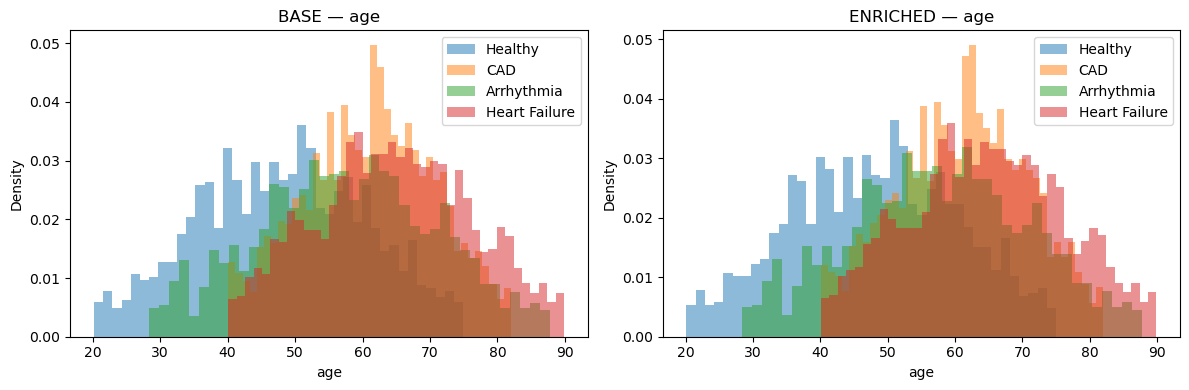

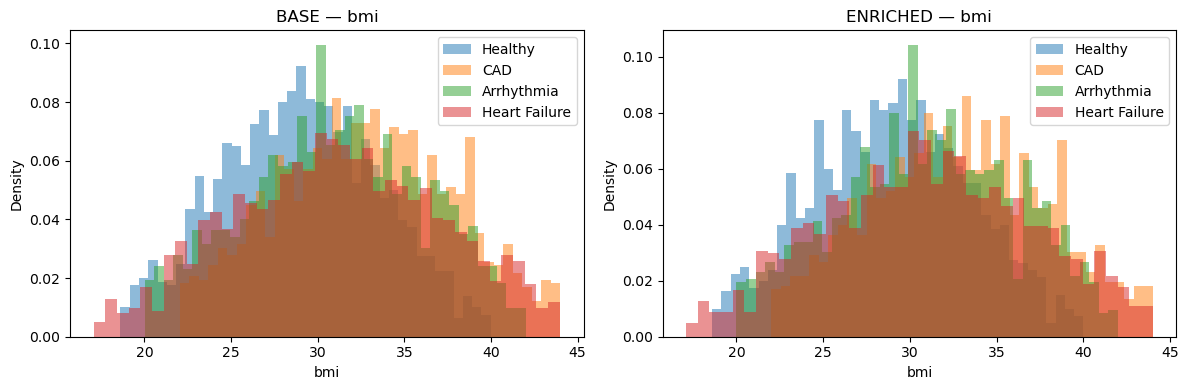

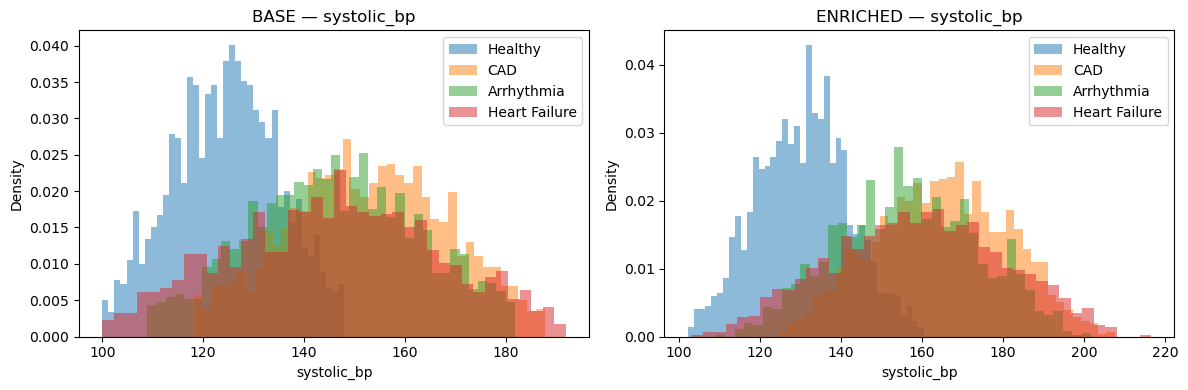

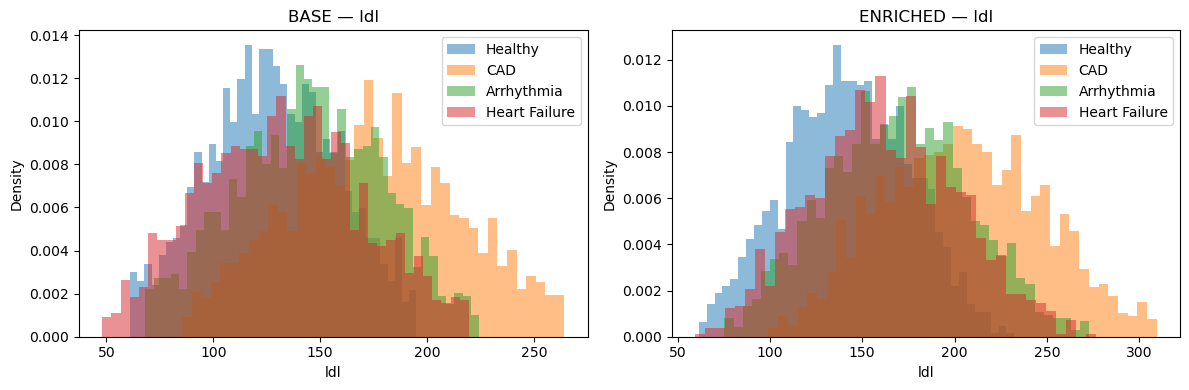

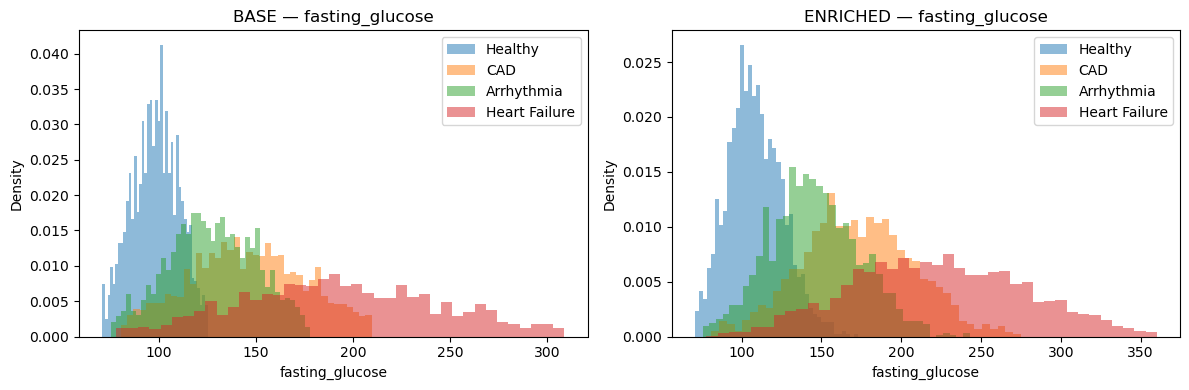

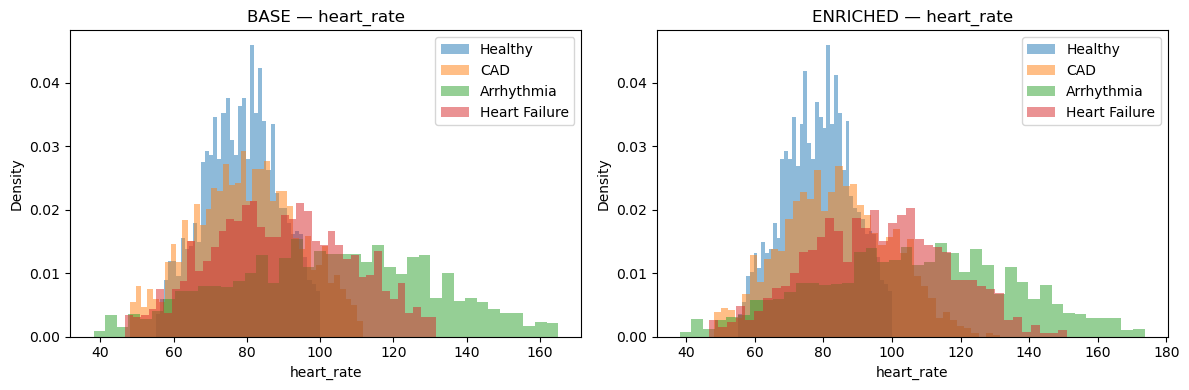

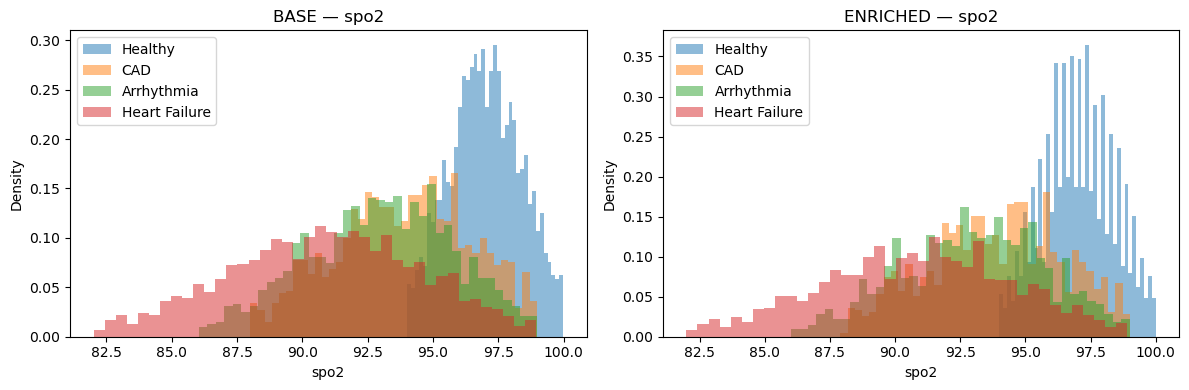

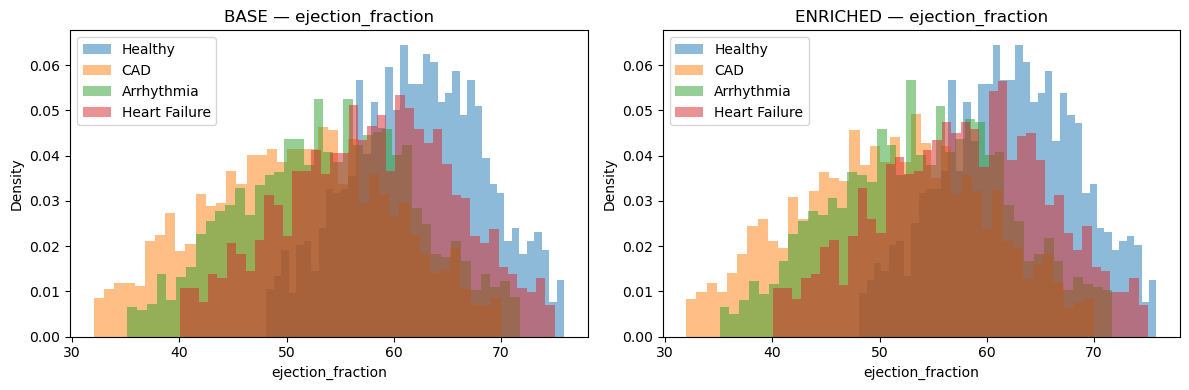

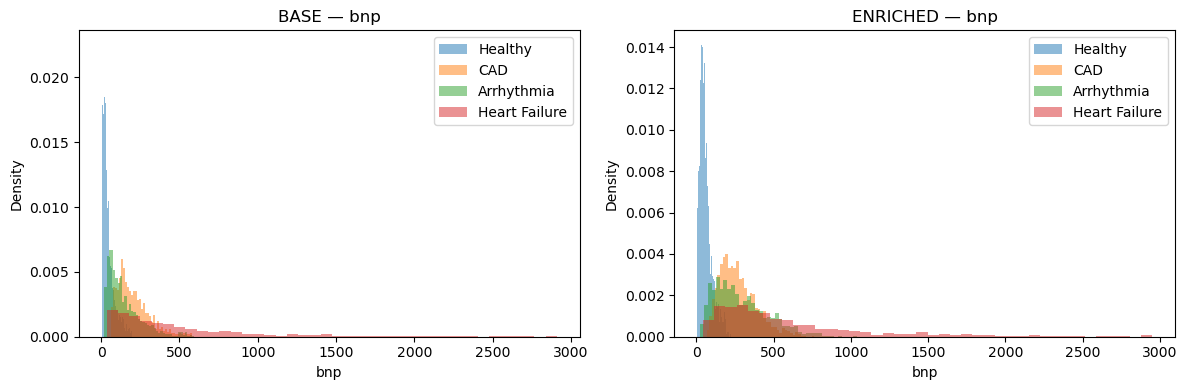

In [31]:
import matplotlib.pyplot as plt

# Features to inspect
features = CONT_COLS

for feat in features:

    plt.figure(figsize=(12, 4))

    # ── Base dataset ─────────────────────────────
    plt.subplot(1, 2, 1)

    for cls in CLASS_NAMES:
        vals = df_base[df_base['target'] == cls][feat]
        plt.hist(vals, bins=40, alpha=0.5, density=True, label=cls)

    plt.title(f'BASE — {feat}')
    plt.xlabel(feat)
    plt.ylabel('Density')
    plt.legend()

    # ── Enriched dataset ─────────────────────────
    plt.subplot(1, 2, 2)

    for cls in CLASS_NAMES:
        vals = df_enriched[df_enriched['target'] == cls][feat]
        plt.hist(vals, bins=40, alpha=0.5, density=True, label=cls)

    plt.title(f'ENRICHED — {feat}')
    plt.xlabel(feat)
    plt.ylabel('Density')
    plt.legend()

    plt.tight_layout()
    plt.show()

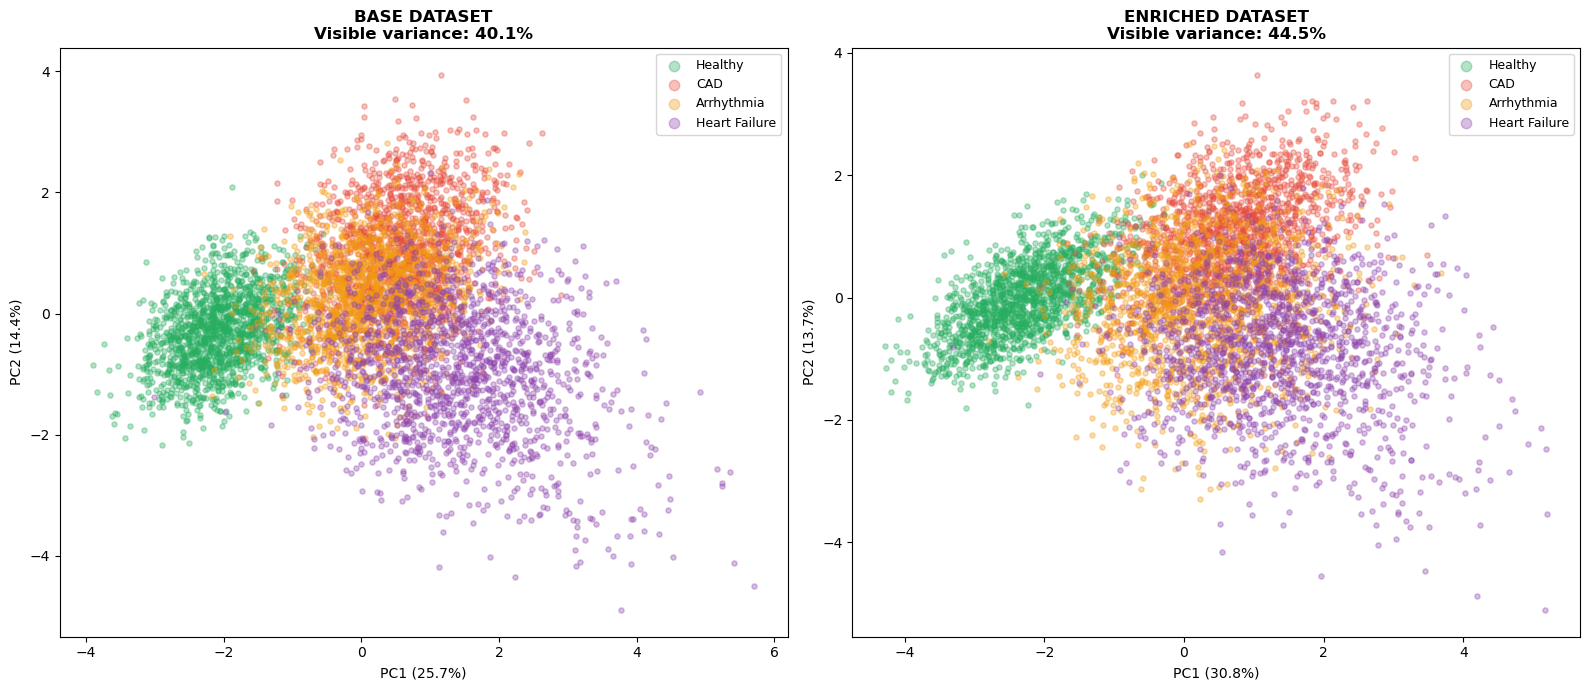

What to look for:
- Too much separation  -> synthetic leakage / unrealistic
- Too much overlap     -> enrichment ineffective
- Moderate overlap     -> more realistic clinical structure


In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

datasets = [
    ('BASE DATASET', df_base, axes[0]),
    ('ENRICHED DATASET', df_enriched, axes[1])
]

for title, df_curr, ax in datasets:

    # ── Scale continuous features ─────────────────────────────
    X = df_curr[CONT_COLS].copy()
    X_scaled = StandardScaler().fit_transform(X)

    # ── PCA projection ───────────────────────────────────────
    pca = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X_scaled)

    var = pca.explained_variance_ratio_ * 100

    # ── Scatter by class ─────────────────────────────────────
    for cls, col in zip(CLASS_NAMES, CLASS_COLORS):

        mask = df_curr['target'] == cls

        ax.scatter(
            X_2d[mask, 0],
            X_2d[mask, 1],
            color=col,
            alpha=0.35,
            s=14,
            label=cls
        )

    ax.set_title(
        title + '\nVisible variance: ' + str(round(sum(var), 1)) + '%',
        fontweight='bold'
    )

    ax.set_xlabel(
        'PC1 (' + str(round(var[0], 1)) + '%)'
    )

    ax.set_ylabel(
        'PC2 (' + str(round(var[1], 1)) + '%)'
    )

    ax.legend(markerscale=2, fontsize=9)

plt.tight_layout()
plt.show()


# ── Interpretation helper ────────────────────────────────────
print('What to look for:')
print('- Too much separation  -> synthetic leakage / unrealistic')
print('- Too much overlap     -> enrichment ineffective')
print('- Moderate overlap     -> more realistic clinical structure')

In [27]:
df_enriched.to_csv('cardiac_dataset.csv',     index=False)
df_base.to_csv('cardiac_dataset_base.csv',    index=False)

metadata = {
    'class_names':  CLASS_NAMES,
    'class_colors': CLASS_COLORS,
    'cont_cols':    CONT_COLS,
    'cat_cols':     CAT_COLS,
    'all_cols':     CONT_COLS + CAT_COLS,
    'n_per_class':  N,
}
with open('cardiac_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print('Files saved: cardiac_dataset.csv  cardiac_dataset_base.csv  cardiac_metadata.pkl')


Files saved: cardiac_dataset.csv  cardiac_dataset_base.csv  cardiac_metadata.pkl


In [28]:
df_enriched.to_csv('cardiac_dataset.csv', index=False)

df_base.to_csv('cardiac_dataset_base.csv', index=False)

metadata = {
    'class_names': CLASS_NAMES, 'class_colors': CLASS_COLORS,
    'cont_cols': CONT_COLS, 'cat_cols': CAT_COLS,
    'all_cols': CONT_COLS + CAT_COLS, 'n_per_class': N
}
with open('cardiac_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print('Saved files:')
print('  cardiac_dataset_base.csv   — base dataset')
print('  cardiac_metadata.pkl')

print()
print('Dataset summary:')
print('  Total patients :', len(df_enriched))
print('  Features       :', len(CONT_COLS + CAT_COLS))
print('  Patients/class :', N)
print('  Classes        :', CLASS_NAMES)

Saved files:
  cardiac_dataset_base.csv   — base dataset
  cardiac_metadata.pkl

Dataset summary:
  Total patients : 6000
  Features       : 16
  Patients/class : 1500
  Classes        : ['Healthy', 'CAD', 'Arrhythmia', 'Heart Failure']


---
## Phase:1 Summary

This notebook built a clinically realistic synthetic patient dataset from scratch using published clinical statistics.

**What we did:**

1. Generated 1500 patients per class (6,000 total) using normal and log-normal distributions
2. Created an enriched dataset by applying clinically-justified medical relationships between features
3. Compared both datasets and selected the base one.

**Next to continue with phase 2: EDA, Modelling, and Evaluation**